<h1>Alzheimer's Disease Prediction - Complete Notebook</h1>

In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# Note: Assumes dataset in local directory: data/alzheimers_disease_data.csv
# ──────────────────────────────────────────────────────────────────────────────

<h2>Imports</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score
)
from sklearn.ensemble import RandomForestClassifier
!pip install torch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import TensorDataset, DataLoader

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# GPU/CPU device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Using device: cpu


<h2>Preprocessing & Data Loading</h2>

In [2]:
def load_and_preprocess_data(file_path='data/alzheimers_disease_data.csv'):
    print("Loading and preprocessing data...")
    df = pd.read_csv(file_path)
    df = df.drop(['PatientID', 'DoctorInCharge'], axis=1)
    
    # Feature engineering
    df['BP_Interaction'] = abs(df['SystolicBP'] - df['DiastolicBP'])
    df['Cholesterol_Ratio'] = df['CholesterolLDL'] / df['CholesterolHDL']
    df['TG_HDL_Index'] = df['CholesterolTriglycerides'] / df['CholesterolHDL']
    
    X = df.drop('Diagnosis', axis=1)
    y = df['Diagnosis']
    
    cat_cols = ['Ethnicity', 'EducationLevel']
    num_cols = [col for col in X.columns if col not in cat_cols]
    
    scaler = StandardScaler()
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_test, y_test, test_size=0.5, stratify=y_test, random_state=42
    )
    
    X_train_num = scaler.fit_transform(X_train[num_cols].values)
    X_val_num   = scaler.transform(X_val[num_cols].values)
    X_test_num  = scaler.transform(X_test[num_cols].values)
    
    X_train_cat = X_train[cat_cols].values
    X_val_cat   = X_val[cat_cols].values
    X_test_cat  = X_test[cat_cols].values
    
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float)
    print("Class weights:", class_weights)
    
    # Tensors
    X_train_num_t = torch.tensor(X_train_num, dtype=torch.float32)
    X_train_cat_t = torch.tensor(X_train_cat, dtype=torch.long)
    y_train_t     = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
    
    X_val_num_t   = torch.tensor(X_val_num,   dtype=torch.float32)
    X_val_cat_t   = torch.tensor(X_val_cat,   dtype=torch.long)
    y_val_t       = torch.tensor(y_val.values,   dtype=torch.float32).unsqueeze(1)
    
    X_test_num_t  = torch.tensor(X_test_num,  dtype=torch.float32)
    X_test_cat_t  = torch.tensor(X_test_cat,  dtype=torch.long)
    y_test_t      = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)
    
    # DataLoaders
    batch_size = 128
    train_loader = DataLoader(TensorDataset(X_train_num_t, X_train_cat_t, y_train_t), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val_num_t,   X_val_cat_t,   y_val_t),   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(TensorDataset(X_test_num_t,  X_test_cat_t,  y_test_t),  batch_size=batch_size, shuffle=False)
    
    print("Data loaders ready.")
    return train_loader, val_loader, test_loader, class_weights, len(num_cols), [X[col].nunique() for col in cat_cols]

<h2>Model Definitions</h2>

In [3]:
class AlzheimerMLP(nn.Module):
    def __init__(self, num_numerical, cat_sizes, embedding_dim=8, hidden_dims=[128, 64], dropout=0.2):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(size, embedding_dim) for size in cat_sizes])
        input_dim = num_numerical + len(cat_sizes) * embedding_dim
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.fc = nn.Sequential(*layers)

    def forward(self, num_inputs, cat_inputs):
        embeds = [emb(cat_inputs[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(embeds + [num_inputs], dim=1)
        return self.fc(x)

class TabTransformer(nn.Module):
    def __init__(self, num_numerical, cat_sizes, emb_dim=32, n_layers=2, n_heads=4, dropout=0.1):
        super().__init__()
        self.cat_embeddings = nn.ModuleList([nn.Embedding(size + 1, emb_dim) for size in cat_sizes])
        self.num_projection = nn.Linear(1, emb_dim)
        self.total_num_tokens = num_numerical + len(cat_sizes) + 1
        self.cls_token = nn.Parameter(torch.zeros(1, 1, emb_dim))
        self.pos_embeddings = nn.Parameter(torch.randn(1, self.total_num_tokens, emb_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=n_heads, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.Linear(emb_dim, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1))

    def forward(self, x_num, x_cat):
        num_emb = self.num_projection(x_num.unsqueeze(-1))
        cat_emb = torch.stack([emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embeddings)], dim=1)
        feature_tokens = torch.cat([num_emb, cat_emb], dim=1)
        cls_tokens = self.cls_token.expand(feature_tokens.size(0), -1, -1)
        tokens = torch.cat([cls_tokens, feature_tokens], dim=1) + self.pos_embeddings
        out = self.transformer_encoder(tokens)
        return self.head(out[:, 0, :])

<h2>Training & Evaluation Utilities</h2>

In [4]:
def train_model(model, train_loader, val_loader, class_weights, epochs=50, lr=0.001, patience=15):
    criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights[1])
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for num_b, cat_b, labels in train_loader:
            num_b, cat_b, labels = num_b.to(device), cat_b.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(num_b, cat_b)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        val_loss, _ = evaluate_model(model, val_loader, criterion)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break
    
    model.load_state_dict(torch.load('best_model.pth'))
    return train_losses, val_losses

def evaluate_model(model, loader, criterion=None):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for num_b, cat_b, labels in loader:
            num_b, cat_b, labels = num_b.to(device), cat_b.to(device), labels.to(device)
            outputs = model(num_b, cat_b)
            if criterion:
                total_loss += criterion(outputs, labels).item()
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())
    avg_loss = total_loss / len(loader) if criterion else None
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    cm = confusion_matrix(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    specificity = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
    
    return avg_loss, {
        'Accuracy': acc, 'F1-Score': f1, 'AUC-ROC': auc,
        'Precision': precision, 'Recall': recall, 'Specificity': specificity,
        'Confusion Matrix': cm
    }

<h2>Exploratory Data Analysis (EDA)</h2>


=== Running EDA ===


/var/folders/17/ny1938053dx4s23s5t5sknxh0000gn/T/ipykernel_38225/2034705083.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diagnosis', data=df, palette='viridis')


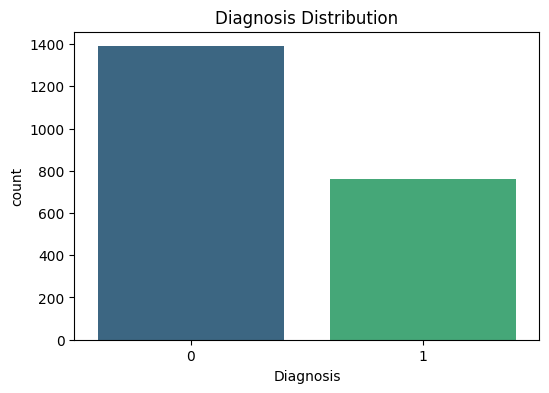

/var/folders/17/ny1938053dx4s23s5t5sknxh0000gn/T/ipykernel_38225/2034705083.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y='Age', data=df, palette='viridis')


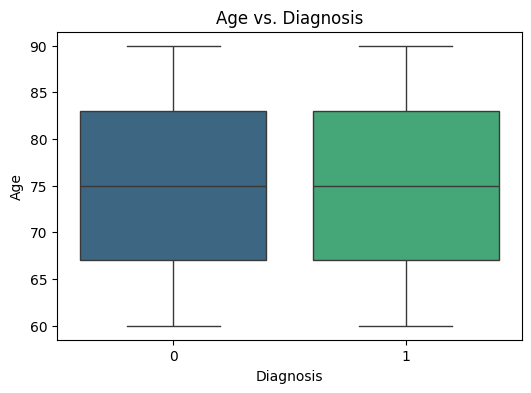

/var/folders/17/ny1938053dx4s23s5t5sknxh0000gn/T/ipykernel_38225/2034705083.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diagnosis', y='BMI', data=df, palette='viridis')


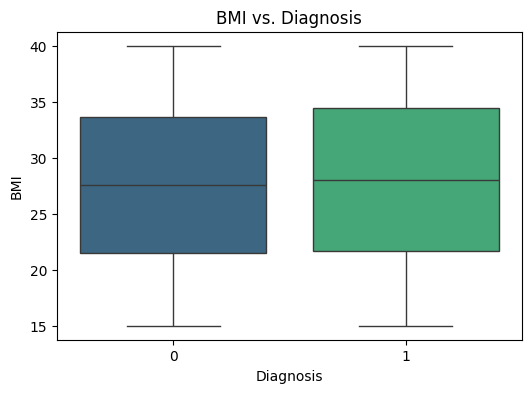

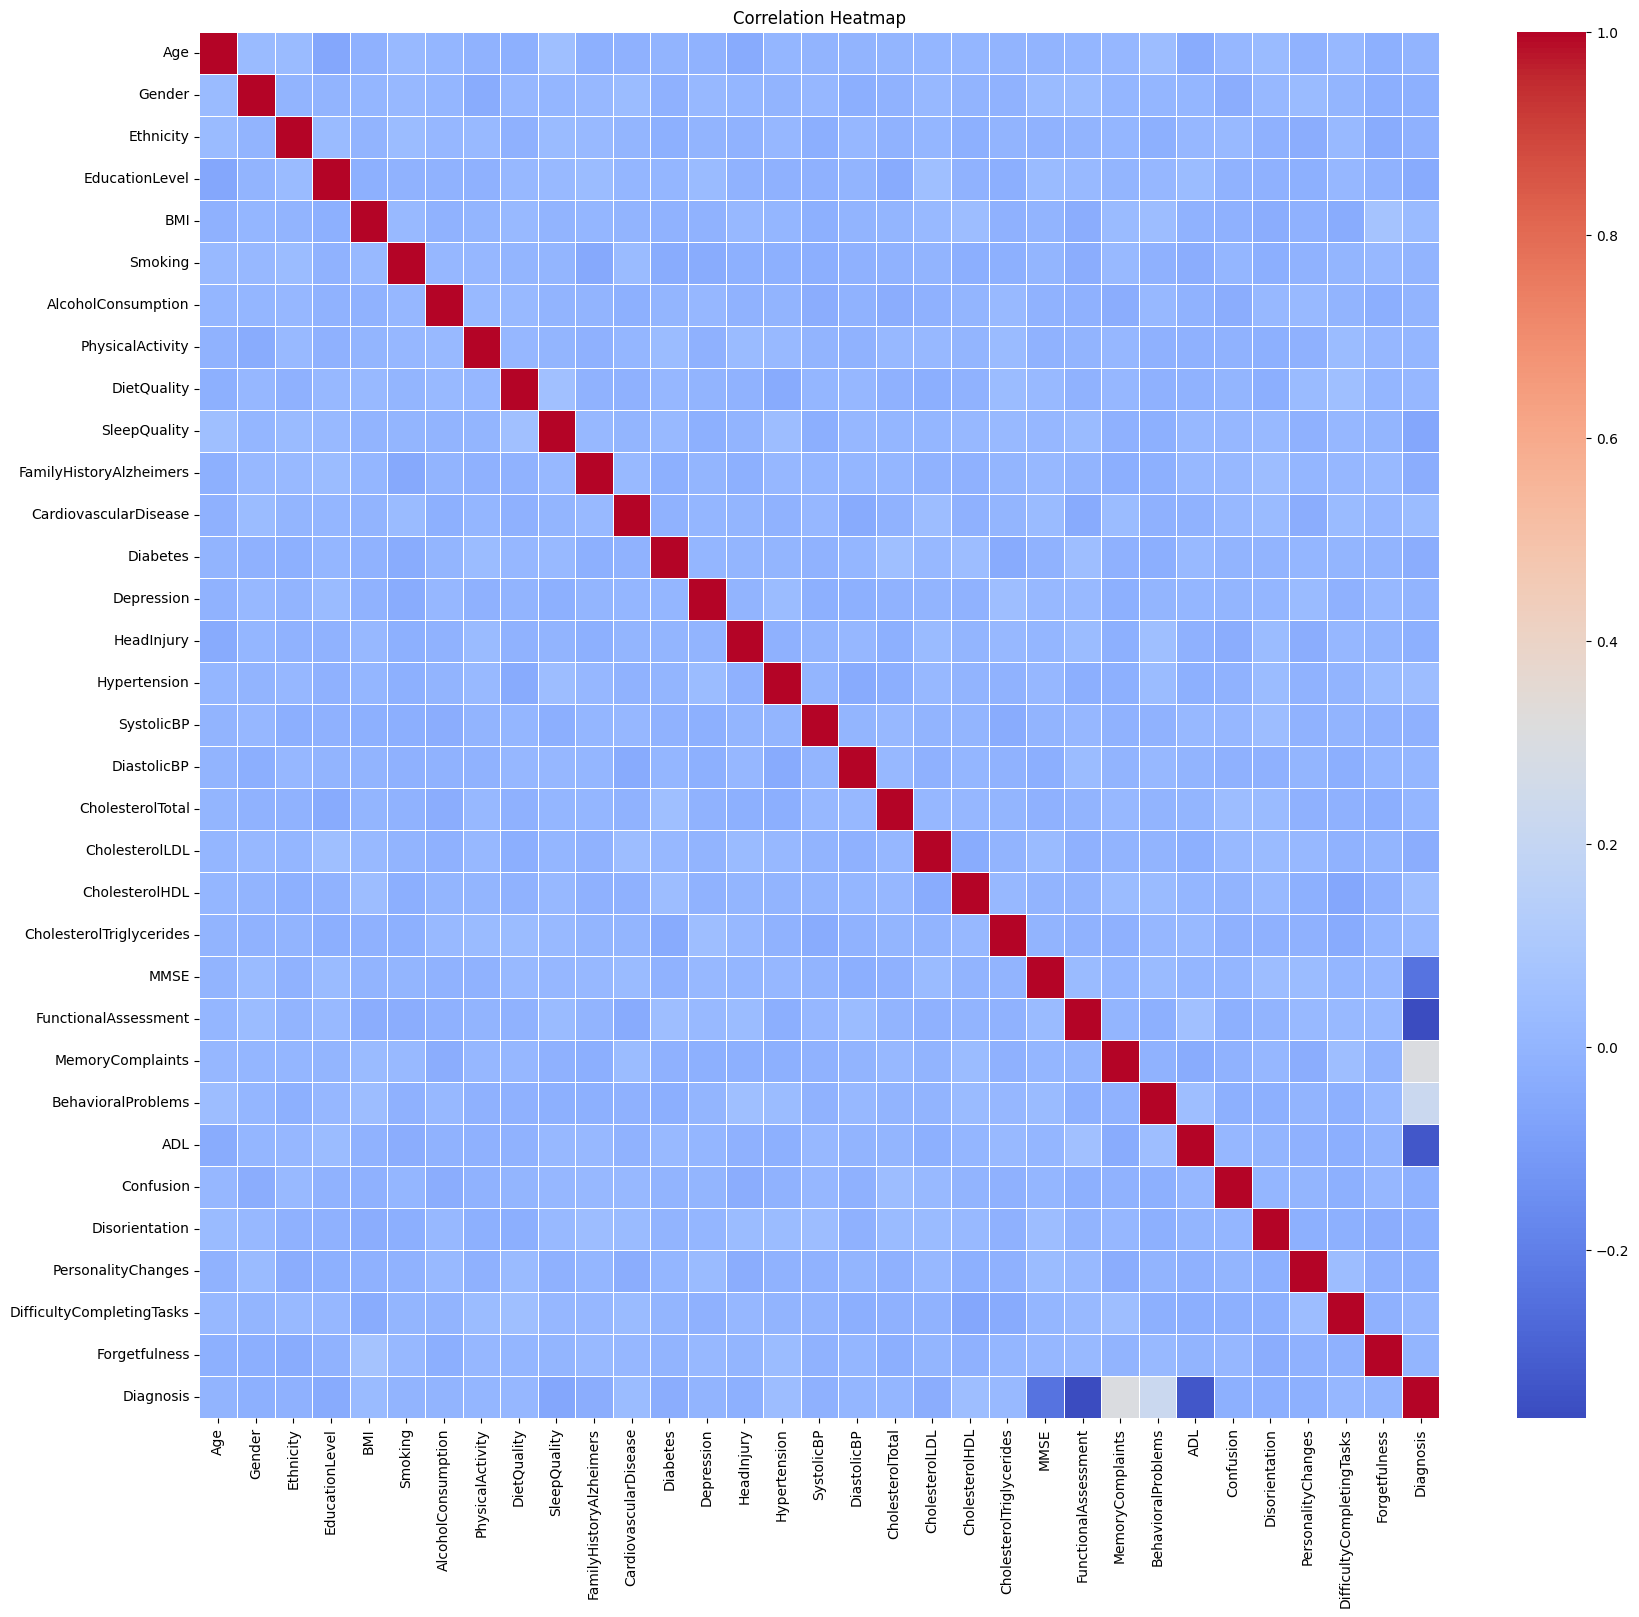

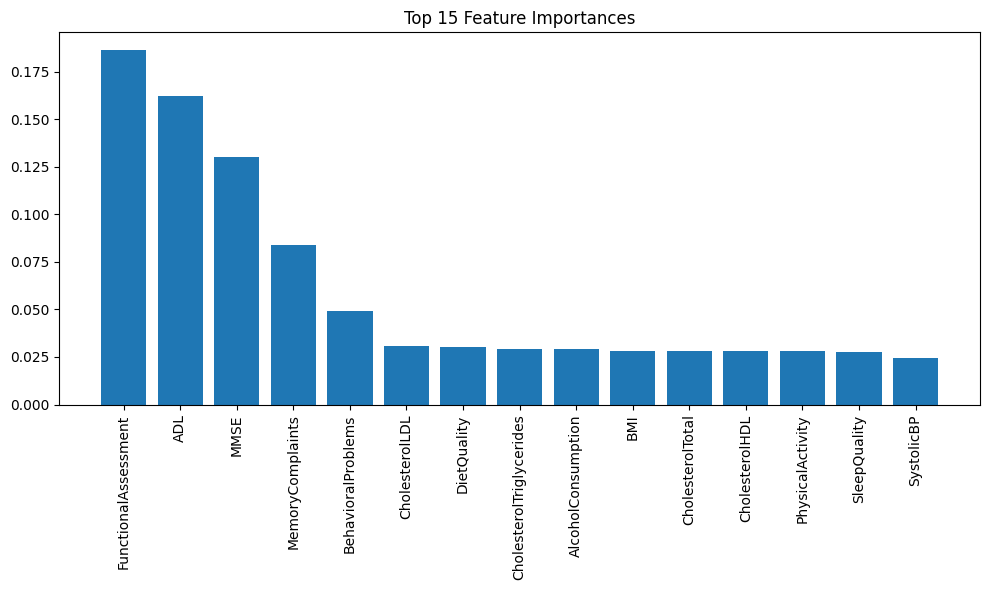

In [5]:
print("\n=== Running EDA ===")
df = pd.read_csv('data/alzheimers_disease_data.csv')
df = df.drop(['PatientID', 'DoctorInCharge'], axis=1)

# Diagnosis Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Diagnosis', data=df, palette='viridis')
plt.title('Diagnosis Distribution')
plt.show()

# Age vs. Diagnosis
plt.figure(figsize=(6,4))
sns.boxplot(x='Diagnosis', y='Age', data=df, palette='viridis')
plt.title('Age vs. Diagnosis')
plt.show()

# BMI vs. Diagnosis
plt.figure(figsize=(6,4))
sns.boxplot(x='Diagnosis', y='BMI', data=df, palette='viridis')
plt.title('BMI vs. Diagnosis')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(20,18))
num_features = df.select_dtypes(include=[np.number])
corr_matrix = num_features.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Feature Importance (Random Forest)
rf = RandomForestClassifier(random_state=42)
rf.fit(num_features.drop('Diagnosis', axis=1), df['Diagnosis'])
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]
plt.figure(figsize=(10,6))
plt.bar(range(15), importances[indices])
plt.xticks(range(15), [num_features.columns[i] for i in indices], rotation=90)
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

<h2> Main Training & Evaluation


=== Starting Model Training ===
Loading and preprocessing data...
Class weights: tensor([0.7737, 1.4135])
Data loaders ready.

Training MLP...
Epoch 1/50 | Train Loss: 0.7738 | Val Loss: 0.7589
Epoch 2/50 | Train Loss: 0.7256 | Val Loss: 0.7067
Epoch 3/50 | Train Loss: 0.6523 | Val Loss: 0.6238
Epoch 4/50 | Train Loss: 0.5610 | Val Loss: 0.5413
Epoch 5/50 | Train Loss: 0.4845 | Val Loss: 0.4895
Epoch 6/50 | Train Loss: 0.4583 | Val Loss: 0.4775
Epoch 7/50 | Train Loss: 0.4258 | Val Loss: 0.4754
Epoch 8/50 | Train Loss: 0.4157 | Val Loss: 0.4746
Epoch 9/50 | Train Loss: 0.3981 | Val Loss: 0.4693
Epoch 10/50 | Train Loss: 0.3952 | Val Loss: 0.4640
Epoch 11/50 | Train Loss: 0.3822 | Val Loss: 0.4583
Epoch 12/50 | Train Loss: 0.3850 | Val Loss: 0.4589
Epoch 13/50 | Train Loss: 0.3747 | Val Loss: 0.4575
Epoch 14/50 | Train Loss: 0.3504 | Val Loss: 0.4580
Epoch 15/50 | Train Loss: 0.3558 | Val Loss: 0.4565
Epoch 16/50 | Train Loss: 0.3321 | Val Loss: 0.4542
Epoch 17/50 | Train Loss: 0.3214 

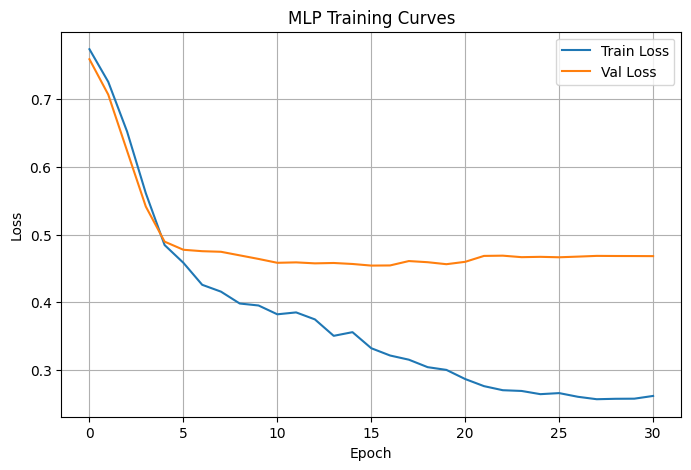

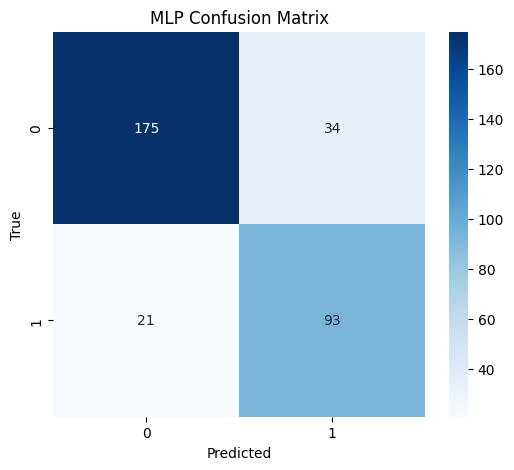


Training TabTransformer...
Epoch 1/50 | Train Loss: 0.7945 | Val Loss: 0.7856
Epoch 2/50 | Train Loss: 0.7859 | Val Loss: 0.7848
Epoch 3/50 | Train Loss: 0.7863 | Val Loss: 0.7852
Epoch 4/50 | Train Loss: 0.7873 | Val Loss: 0.7852
Epoch 5/50 | Train Loss: 0.7844 | Val Loss: 0.7831
Epoch 6/50 | Train Loss: 0.7796 | Val Loss: 0.7563
Epoch 7/50 | Train Loss: 0.7274 | Val Loss: 0.7084
Epoch 8/50 | Train Loss: 0.7010 | Val Loss: 0.6895
Epoch 9/50 | Train Loss: 0.6515 | Val Loss: 0.5917
Epoch 10/50 | Train Loss: 0.6162 | Val Loss: 0.5568
Epoch 11/50 | Train Loss: 0.5722 | Val Loss: 0.5144
Epoch 12/50 | Train Loss: 0.5331 | Val Loss: 0.4997
Epoch 13/50 | Train Loss: 0.4663 | Val Loss: 0.3929
Epoch 14/50 | Train Loss: 0.4205 | Val Loss: 0.4281
Epoch 15/50 | Train Loss: 0.4411 | Val Loss: 0.3687
Epoch 16/50 | Train Loss: 0.3858 | Val Loss: 0.3798
Epoch 17/50 | Train Loss: 0.3289 | Val Loss: 0.3038
Epoch 18/50 | Train Loss: 0.3001 | Val Loss: 0.2861
Epoch 19/50 | Train Loss: 0.2720 | Val Loss: 

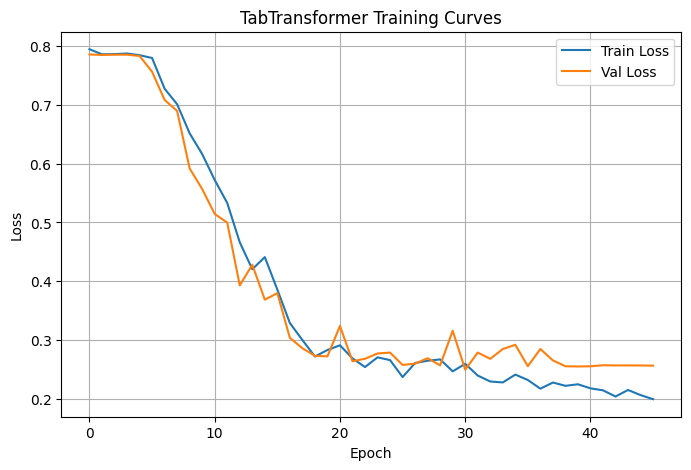

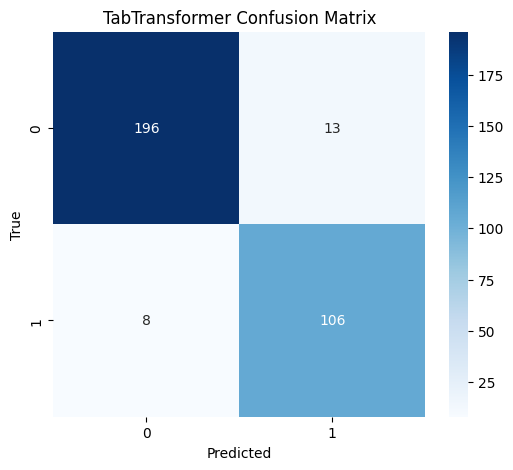


=== All training and evaluation complete ===


In [6]:
print("\n=== Starting Model Training ===")

train_loader, val_loader, test_loader, class_weights, num_numerical, cat_sizes = load_and_preprocess_data()

# ── Model 1: MLP ─────────────────────────────────────────────────────────────
model_mlp = AlzheimerMLP(num_numerical, cat_sizes)
model_mlp.to(device)

print("\nTraining MLP...")
train_losses_mlp, val_losses_mlp = train_model(model_mlp, train_loader, val_loader, class_weights)

_, metrics_mlp = evaluate_model(model_mlp, test_loader)
print("\nMLP Test Metrics:")
for k, v in metrics_mlp.items():
    if k != 'Confusion Matrix':
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}:\n{v}")

# Plots
plt.figure(figsize=(8,5))
plt.plot(train_losses_mlp, label='Train Loss')
plt.plot(val_losses_mlp, label='Val Loss')
plt.title('MLP Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(metrics_mlp['Confusion Matrix'], annot=True, fmt='d', cmap='Blues')
plt.title('MLP Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ── Model 2: TabTransformer ──────────────────────────────────────────────────
model_tab = TabTransformer(num_numerical, cat_sizes)
model_tab.to(device)

print("\nTraining TabTransformer...")
train_losses_tab, val_losses_tab = train_model(model_tab, train_loader, val_loader, class_weights)

_, metrics_tab = evaluate_model(model_tab, test_loader)
print("\nTabTransformer Test Metrics:")
for k, v in metrics_tab.items():
    if k != 'Confusion Matrix':
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}:\n{v}")

# Plots
plt.figure(figsize=(8,5))
plt.plot(train_losses_tab, label='Train Loss')
plt.plot(val_losses_tab, label='Val Loss')
plt.title('TabTransformer Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(metrics_tab['Confusion Matrix'], annot=True, fmt='d', cmap='Blues')
plt.title('TabTransformer Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print("\n=== All training and evaluation complete ===")